In [3]:
import pandas as pd
import numpy as np
from datetime import datetime
from scipy import stats
from scipy.stats import f as f_dist

from setting_for_sda.path_setting import path_list
from setting_for_sda.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.utils.datetime_handler import calc_rel_period
from lib.visualization.distribution_collector import (calc_top_bottom_tags_prop)
from matplotlib import pyplot as plt
from lib.visualization.plot_generator import PlotGen

import matplotlib as mpl
# import lib.visualization.font_setting as font_setting
# mpl.rcParams.update(font_setting.fig_setting)
import matplotlib.pyplot as plt





In [5]:
chk_dict = dict()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    plotgen = PlotGen()
    print(f'[Start....] Aggreagate data for {lang} language')

    tmp = load_df(plotgen.data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'cdate', period = 7).reset_index()
    
    proportion_dict = calc_top_bottom_tags_prop(tmp)
    chk_dict[lang] = proportion_dict

    draw_bar_plot_for_tag(idx, proportion_dict, option_dict, output_dir)
    draw_scatter_line_plot_for_tag(idx, proportion_dict, option_dict, output_dir)
    print(f'[End....] drawing figures for {lang} language')

    

[Start....] Aggreagate data for python language


AttributeError: 'PlotGen' object has no attribute 'data_dir'

In [13]:
lang = 'python'
idx = 0
chk_dict = dict()
# plotgen = PlotGen(idx = 100+idx, model_in_run='tag')
print(f'[Start....] Aggreagate data for {lang} language')

viz_dir = '/mnt/hdd/mghan/so_data_availability/result/tag/run_id_100'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")
std_date = Date_Setting[option_dict['year_range']]['std_date']


tmp = load_df(data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'cdate', period = 7).reset_index()

proportion_dict = calc_top_bottom_tags_prop(tmp)
chk_dict[lang] = proportion_dict

[Start....] Aggreagate data for python language


AttributeError: 'PlotGen' object has no attribute 'std_date'

In [ ]:

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib as mpl
# from scipy import stats

# ============================================================
# 공통 컬러 팔레트
# ============================================================
PALETTE = {
    'primary':    '#1f4e79',
    'primary_lt': '#A9CCE3',
    'accent':     '#E07A1F',
    'event':      '#C0392B',
    'neutral':    '#555555',
    'point':      '#BBBBBB',
    'bg_pre':     '#F2F2F2',
}

# ============================================================
# 1. 데이터 (본인 데이터로 교체)
# ============================================================
# df_top    = pd.read_csv('top20.csv')
# df_bottom = pd.read_csv('bottom20.csv')

# --- 예시 더미 ---

df_top = pd.DataFrame({'rel_week': list(proportion_dict['Top 20% Tags']['rel_week']),
                       'share': list(proportion_dict['Top 20% Tags']['pct_pct'])})

df_bottom = pd.DataFrame({'rel_week': list(proportion_dict['Bottom 20% Tags']['rel_week']),
                          'share': list(proportion_dict['Bottom 20% Tags']['pct_pct'])})
# -----------------------

TIME_COL  = 'rel_week'
VALUE_COL = 'share'
XLABEL    = 'Weeks relative to ChatGPT release'
YLABEL    = 'Accumulated tag share'
TITLES    = ['Top 20% tags', 'Bottom 20% tags']

OUT_PNG = 'figure_segmented.png'
OUT_PDF = 'figure_segmented.pdf'


In [16]:
# ============================================================
# Chow test + 회귀계수 반환
# ============================================================
def chow_test(x, y, break_point=0):
    x = np.asarray(x); y = np.asarray(y)
    pre  = x <  break_point
    post = x >= break_point
    n = len(x); k = 2

    s_all, i_all, *_ = stats.linregress(x, y)
    rss_pool = np.sum((y - (s_all*x + i_all))**2)
    res_pre  = stats.linregress(x[pre],  y[pre])
    res_post = stats.linregress(x[post], y[post])
    rss_seg = (np.sum((y[pre]  - (res_pre.slope*x[pre]   + res_pre.intercept))**2) +
               np.sum((y[post] - (res_post.slope*x[post] + res_post.intercept))**2))
    F = ((rss_pool - rss_seg) / k) / (rss_seg / (n - 2*k))
    p = 1 - f_dist.cdf(F, k, n - 2*k)
    return p, res_pre, res_post

# ============================================================
# 회귀 신뢰구간 계산
# ============================================================
def regression_ci(x, y, xs, alpha=0.05):
    """주어진 xs 좌표에서 회귀선의 95% 신뢰구간 계산"""
    x = np.asarray(x); y = np.asarray(y); xs = np.asarray(xs)
    n = len(x)
    slope, intercept, *_ = stats.linregress(x, y)
    y_pred = slope * x + intercept
    resid = y - y_pred
    s_err = np.sqrt(np.sum(resid**2) / (n - 2))
    x_mean = x.mean()
    ss_x = np.sum((x - x_mean)**2)
    t_val = stats.t.ppf(1 - alpha/2, n - 2)
    ci = t_val * s_err * np.sqrt(1/n + (xs - x_mean)**2 / ss_x)
    fit = slope * xs + intercept
    return fit, fit - ci, fit + ci


TTLibError: not enough 'glyf' table data

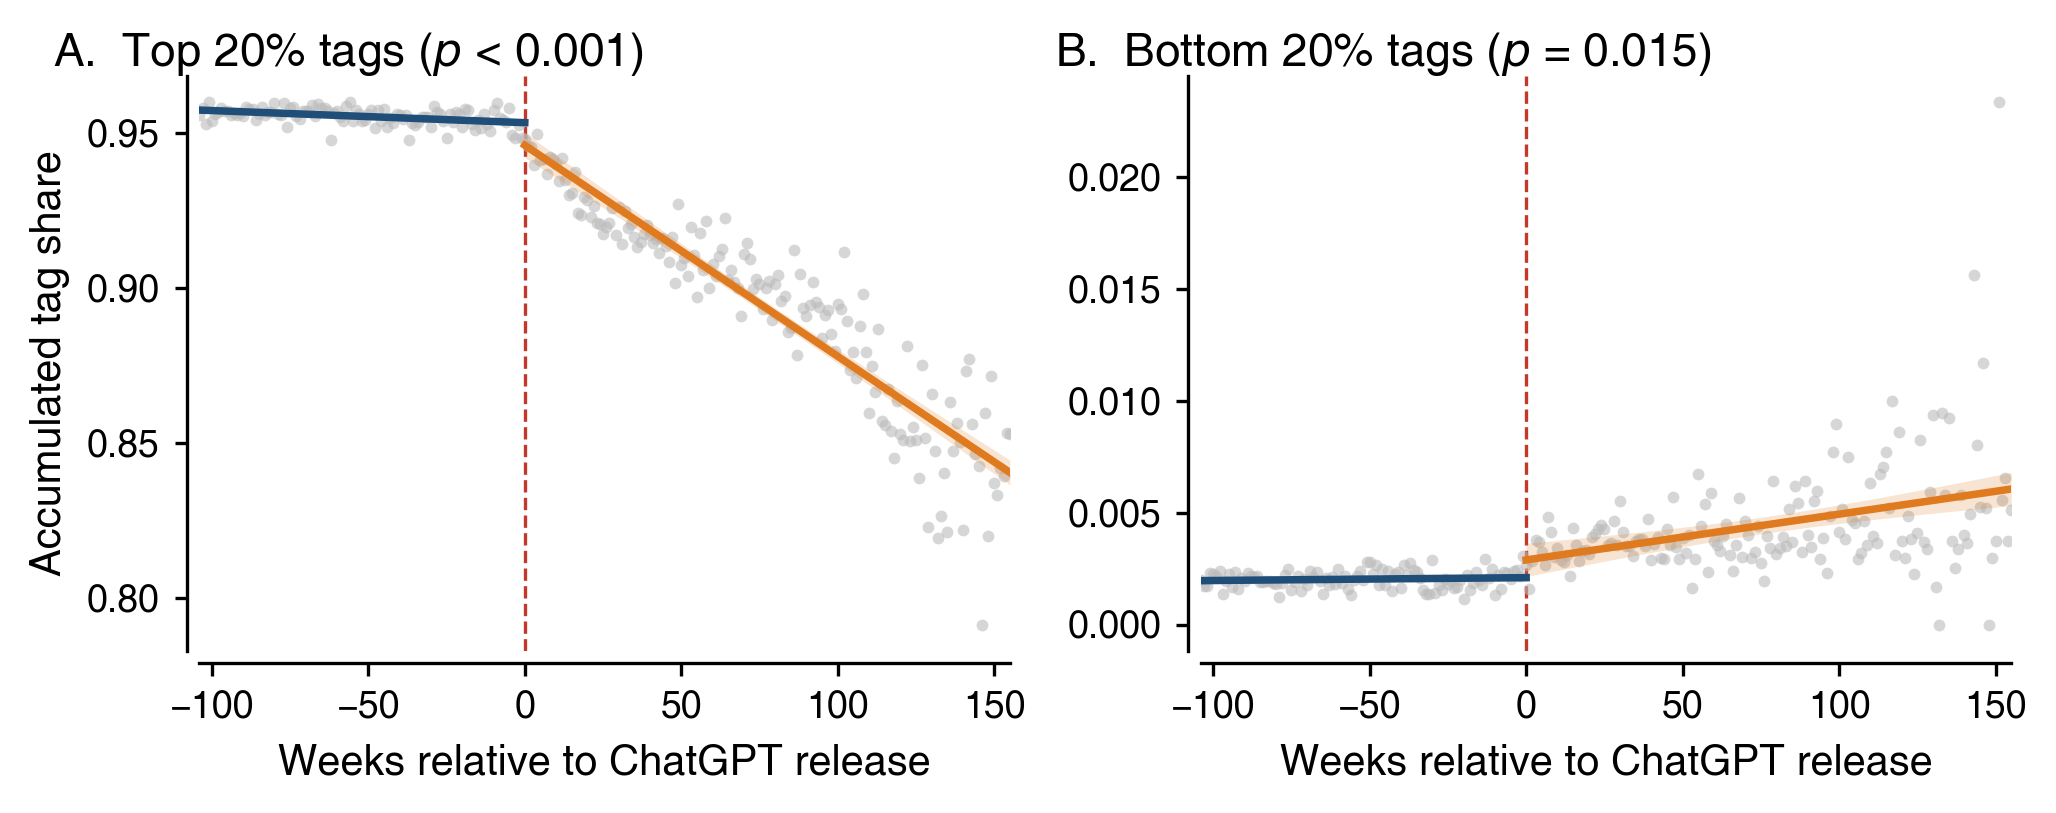

In [21]:
# ============================================================
# 패널 그리기
# ============================================================
def plot_panel(ax, df, title, panel_lbl):
    df = df.sort_values('rel_week').reset_index(drop=True)
    x = df['rel_week'].values
    y = df['share'].values.astype(float)
    pre  = x < 0
    post = x >= 0

    p_chow, _, _ = chow_test(x, y, 0)

    # 산점도
    ax.scatter(x, y, s=8, color=PALETTE['point'], alpha=0.6, lw=0, zorder=2)

    # Segmented fit + CI
    xs_pre  = np.linspace(x[pre].min(),  0, 100)
    xs_post = np.linspace(0, x[post].max(), 100)
    fit_pre,  lo_pre,  hi_pre  = regression_ci(x[pre],  y[pre],  xs_pre)
    fit_post, lo_post, hi_post = regression_ci(x[post], y[post], xs_post)

    ax.fill_between(xs_pre,  lo_pre,  hi_pre,  color=PALETTE['primary'], alpha=0.2, lw=0, zorder=3)
    ax.plot(xs_pre,  fit_pre,  color=PALETTE['primary'], lw=1.8, zorder=4)
    ax.fill_between(xs_post, lo_post, hi_post, color=PALETTE['accent'],  alpha=0.2, lw=0, zorder=3)
    ax.plot(xs_post, fit_post, color=PALETTE['accent'],  lw=1.8, zorder=4)

    # 이벤트 점선
    ax.axvline(0, color=PALETTE['event'], lw=0.8, ls='--', zorder=1)

    # 제목 — 그래프 위쪽
    # ax.set_title(f'{panel_lbl}.  {title}',
    #          fontsize=10, loc='left', pad=8,
    #          fontweight='bold', color='#333')

    # p-value — 안전하게 좌상단 안쪽
    p_text = '$p$ < 0.001' if p_chow < 0.001 else f'$p$ = {p_chow:.3f}'
    # ax.text(0.03, 0.97, p_text, transform=ax.transAxes,
    #         fontsize=9, color=PALETTE['event'],
    #         va='top', ha='left', fontweight='bold')

    # 패널 라벨
    ax.text(-0.18, 1.08, f'{panel_lbl}.  {title} ({p_text})', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left')

    # Spine
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['left'].set_position(('outward', 3))
    ax.spines['bottom'].set_position(('outward', 3))

    ax.set_xlabel('Weeks relative to ChatGPT release')
    ax.set_xlim(x.min(), x.max())
    ax.grid(False)

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), dpi=300)
plot_panel(axes[0], df_top,    'Top 20% tags',    'A')
plot_panel(axes[1], df_bottom, 'Bottom 20% tags', 'B')
axes[0].set_ylabel('Accumulated tag share')

plt.tight_layout()
plt.savefig('figure_segmented.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('figure_segmented.pdf',           bbox_inches='tight', facecolor='white')
plt.show()

TTLibError: not enough 'glyf' table data

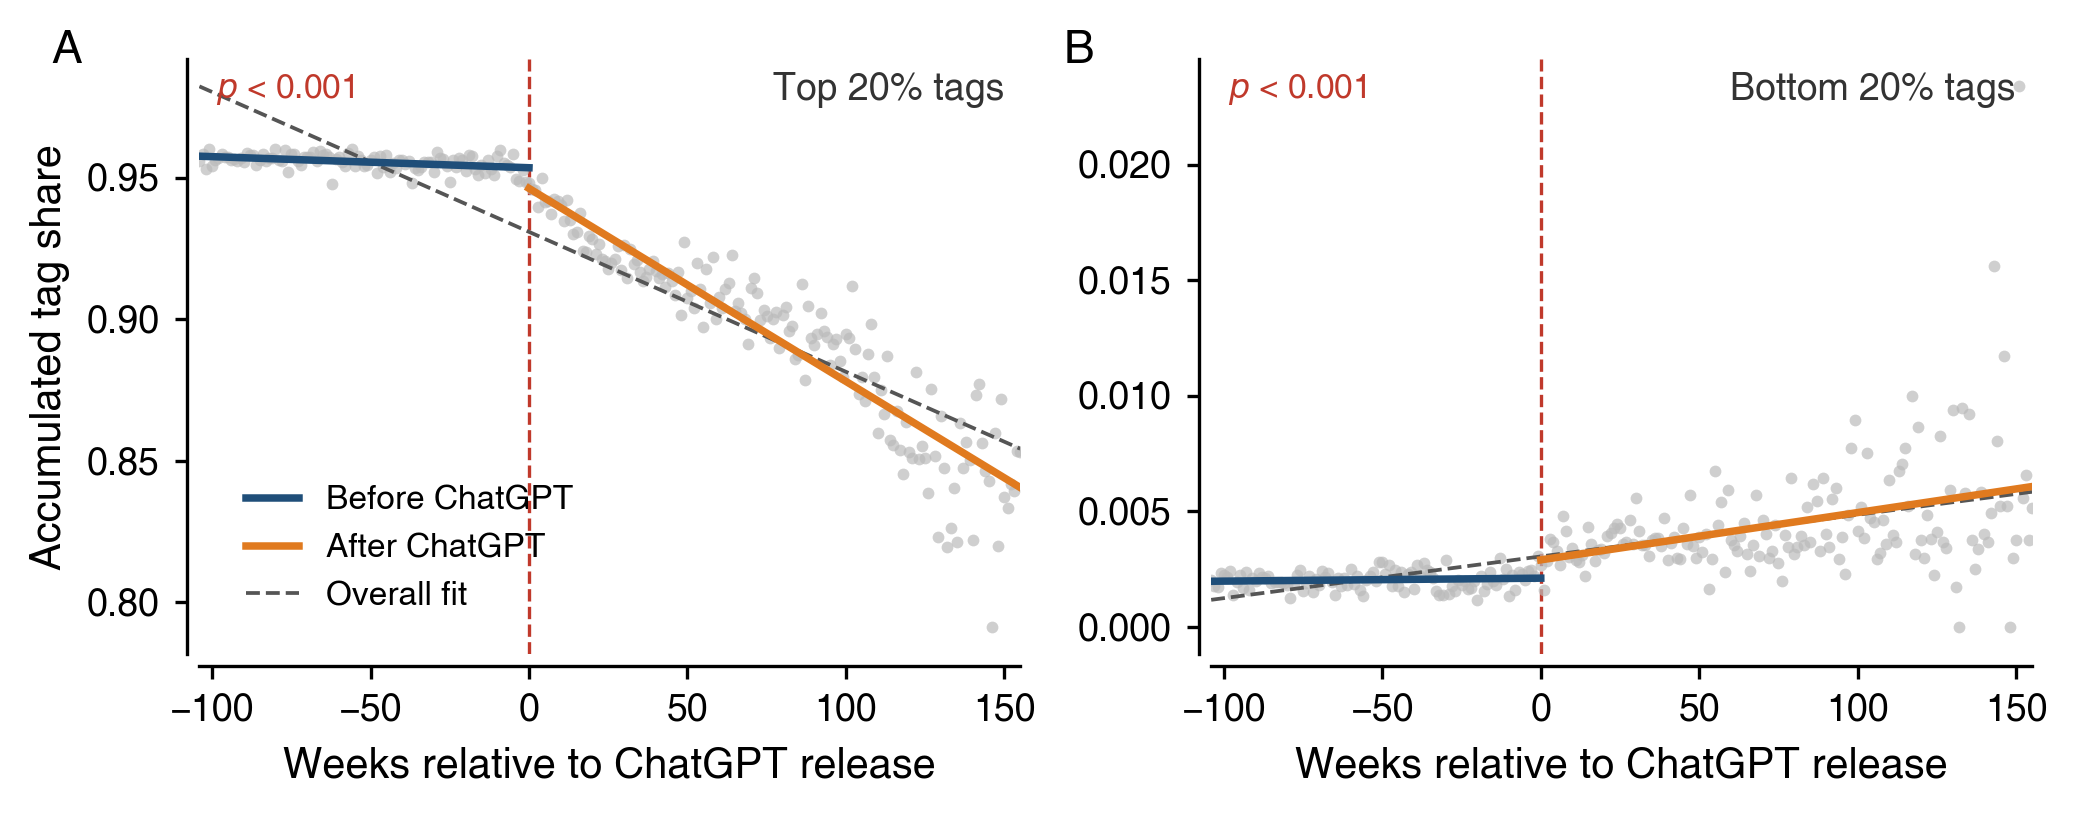

In [11]:

# ============================================================
# 4. Figure
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), dpi=300)

plot_panel(axes[0], df_top,    TITLES[0], 'A', show_legend=True)
plot_panel(axes[1], df_bottom, TITLES[1], 'B', show_legend=False)

axes[0].set_ylabel(YLABEL)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(OUT_PDF,           bbox_inches='tight', facecolor='white')
plt.show()